## Quantum 3SAT Solver using Grover's Algorithm

This notebook demonstrates solving 3SAT problems using Grover's quantum algorithm with CSV data input.

**Author:** Quantum-IBMi-Docker Project  
**Based on:** Jack Woehr's COMMON 2021 Presentation

### Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import math
from typing import List, Tuple, Optional

# Qiskit imports (latest structure)
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

from IPython.display import Markdown, display

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


### Load 3SAT Instance from CSV

In [2]:
# Read the CSV file
df = pd.read_csv('threesat_data.csv')

print(f"✓ Loaded {len(df)} clauses from threesat_data.csv")
print(f"\nData preview:")
display(df)

✓ Loaded 5 clauses from threesat_data.csv

Data preview:


,c1,c2,c3,c4
0,-1,-2,-3,0
1,1,-2,3,0
2,1,2,-3,0
3,1,-2,-3,0
4,-1,2,3,0


### Convert CSV Data to DIMACS CNF Format

In [3]:
# Convert to DIMACS CNF format
max_var = 0
clauses = []

for _, row in df.iterrows():
    clause = []
    # Extract c1, c2, c3, c4 values (case-insensitive)
    for col in ['c1', 'c2', 'c3', 'c4']:
        if col in df.columns:
            literal = int(row[col])
            if literal != 0:  # 0 means unused position
                clause.append(literal)
                max_var = max(max_var, abs(literal))
    
    if clause:  # Only add non-empty clauses
        clauses.append(clause)

if not clauses:
    raise Exception("No valid clauses found")

# Build DIMACS CNF format string
cnf_lines = [f"c 3SAT instance from CSV file"]
cnf_lines.append(f"p cnf {max_var} {len(clauses)}")

for clause in clauses:
    cnf_lines.append(" ".join(map(str, clause)) + " 0")

cnf_formula = "\n".join(cnf_lines)

print(f"✓ Retrieved 3SAT instance with {len(clauses)} clauses and {max_var} variables")
print(f"\nCNF Formula:\n{cnf_formula}")

✓ Retrieved 3SAT instance with 5 clauses and 3 variables

CNF Formula:
c 3SAT instance from CSV file
p cnf 3 5
-1 -2 -3 0
1 -2 3 0
1 2 -3 0
1 -2 -3 0
-1 2 3 0


### Parse DIMACS CNF Format

In [4]:
def parse_dimacs_cnf(cnf_string: str) -> Tuple[int, List[List[int]]]:
    """Parse DIMACS CNF format string"""
    lines = cnf_string.strip().split('\n')
    num_vars = 0
    parsed_clauses = []
    
    for line in lines:
        line = line.strip()
        
        # Skip comments and empty lines
        if not line or line.startswith('c'):
            continue
        
        # Parse problem line
        if line.startswith('p cnf'):
            parts = line.split()
            num_vars = int(parts[2])
            continue
        
        # Parse clause
        clause = [int(x) for x in line.split() if x != '0']
        if clause:
            parsed_clauses.append(clause)
    
    return num_vars, parsed_clauses

num_vars, parsed_clauses = parse_dimacs_cnf(cnf_formula)
print(f"✓ Parsed {len(parsed_clauses)} clauses with {num_vars} variables")

✓ Parsed 5 clauses with 3 variables


### Create Quantum Oracle from 3SAT Clauses

In [5]:
def create_oracle_from_clauses(num_vars: int, clauses: List[List[int]]) -> QuantumCircuit:
    """Create a phase oracle from 3SAT clauses"""
    oracle = QuantumCircuit(num_vars)
    
    # For each clause, mark the state that violates it
    for clause in clauses:
        # A clause is violated when all literals are false
        clause_qc = QuantumCircuit(num_vars)
        
        # Apply X gates to flip qubits for negative literals
        for literal in clause:
            if literal < 0:
                clause_qc.x(abs(literal) - 1)
        
        # Apply multi-controlled Z gate (marks the violating state)
        if len(clause) == 1:
            clause_qc.z(abs(clause[0]) - 1)
        else:
            controls = [abs(lit) - 1 for lit in clause]
            clause_qc.mcx(controls[:-1], controls[-1])
            clause_qc.z(controls[-1])
            clause_qc.mcx(controls[:-1], controls[-1])
        
        # Undo the X gates
        for literal in clause:
            if literal < 0:
                clause_qc.x(abs(literal) - 1)
        
        oracle.compose(clause_qc, inplace=True)
    
    return oracle

oracle = create_oracle_from_clauses(num_vars, parsed_clauses)
print(f"✓ Oracle created with {len(parsed_clauses)} clauses")
print(f"\nOracle circuit (first 100 gates):")
oracle.draw('text')

✓ Oracle created with 5 clauses

Oracle circuit (first 100 gates):


┌───┐               ┌───┐                                             »
q_0: ┤ X ├──■─────────■──┤ X ├───────■─────────■─────────■─────────■───────»
     ├───┤  │         │  ├───┤┌───┐  │         │  ┌───┐  │         │  ┌───┐»
q_1: ┤ X ├──■─────────■──┤ X ├┤ X ├──■─────────■──┤ X ├──■─────────■──┤ X ├»
     ├───┤┌─┴─┐┌───┐┌─┴─┐├───┤└───┘┌─┴─┐┌───┐┌─┴─┐├───┤┌─┴─┐┌───┐┌─┴─┐├───┤»
q_2: ┤ X ├┤ X ├┤ Z ├┤ X ├┤ X ├─────┤ X ├┤ Z ├┤ X ├┤ X ├┤ X ├┤ Z ├┤ X ├┤ X ├»
     └───┘└───┘└───┘└───┘└───┘     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«                         ┌───┐               ┌───┐
«q_0: ───────■─────────■──┤ X ├──■─────────■──┤ X ├
«            │         │  ├───┤  │         │  └───┘
«q_1: ───────■─────────■──┤ X ├──■─────────■───────
«     ┌───┐┌─┴─┐┌───┐┌─┴─┐├───┤┌─┴─┐┌───┐┌─┴─┐     
«q_2: ┤ X ├┤ X ├┤ Z ├┤ X ├┤ X ├┤ X ├┤ Z ├┤ X ├─────
«     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘

### Solve with Grover's Algorithm

In [6]:
# Calculate optimal number of iterations
num_solutions = 1  # Assume at least one solution
total_states = 2 ** num_vars
optimal_iterations = int(math.pi / 4 * math.sqrt(total_states / num_solutions))
optimal_iterations = max(1, min(optimal_iterations, 10))  # Limit iterations

print(f"Using {optimal_iterations} Grover iterations")

# Create Grover circuit
grover_circuit = QuantumCircuit(num_vars, num_vars)

# Initialize superposition
grover_circuit.h(range(num_vars))

# Apply Grover iterations
for iteration in range(optimal_iterations):
    # Apply oracle
    grover_circuit.compose(oracle, inplace=True)
    
    # Apply diffusion operator
    grover_circuit.h(range(num_vars))
    grover_circuit.x(range(num_vars))
    
    # Multi-controlled Z
    if num_vars > 1:
        grover_circuit.h(num_vars - 1)
        grover_circuit.mcx(list(range(num_vars - 1)), num_vars - 1)
        grover_circuit.h(num_vars - 1)
    else:
        grover_circuit.z(0)
    
    grover_circuit.x(range(num_vars))
    grover_circuit.h(range(num_vars))

# Measure
grover_circuit.measure(range(num_vars), range(num_vars))

print("✓ Grover circuit constructed")

Using 2 Grover iterations
✓ Grover circuit constructed


### Run Quantum Simulation

In [7]:
# Run on simulator
backend = AerSimulator()
transpiled = transpile(grover_circuit, backend)
job = backend.run(transpiled, shots=1024)
result = job.result()
counts = result.get_counts()

# Get most frequent measurement
top_measurement = max(counts, key=counts.get)

print("✓ Quantum simulation completed")
print(f"\nTop measurement: {top_measurement}")
print(f"Measurement count: {counts[top_measurement]}/1024")

✓ Quantum simulation completed

Top measurement: 010
Measurement count: 143/1024


### Display Results

In [8]:
print("\n" + "="*60)
print("QUANTUM 3SAT SOLUTION RESULTS")
print("="*60)

print(f"\nTop measurement: {top_measurement}")
print(f"Number of Grover iterations: {optimal_iterations}")

# Display variable assignments
print("\nVariable assignments:")
for i in range(num_vars):
    var_value = top_measurement[-(i+1)] if i < len(top_measurement) else '?'
    print(f"  x{i+1} = {var_value} (qubit {i})")

print("\n" + "="*60)


QUANTUM 3SAT SOLUTION RESULTS

Top measurement: 010
Number of Grover iterations: 2

Variable assignments:
  x1 = 0 (qubit 0)
  x2 = 1 (qubit 1)
  x3 = 0 (qubit 2)



### Visualize Results

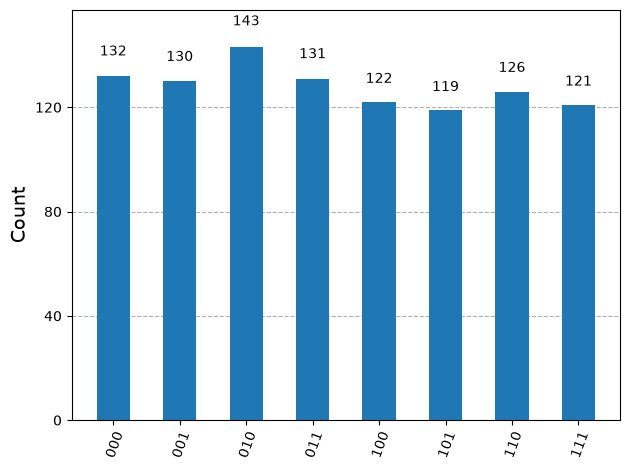

In [9]:
# Plot histogram of measurement results
plot_histogram(counts)